# Load and Fetch Packages and Data

In [ ]:
%pip install git+https://github.com/openai/CLIP.git
%pip install numpy pandas scikit-learn

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-t1nqdh2z
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-t1nqdh2z
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=d143eaa32d9e77aff05d06576dec08209894e942963c759c0089cc241275a375
  Stored in directory: /tmp/pip-ephem-wheel-cache-_vrvk39x/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import os

file_name = "Task 2 NLP Dataset.zip"

if os.path.exists(file_name):
  print("File Exists, beginnning unzip")
  !unzip "Task 2 NLP Dataset"
  print("File unzipped")
else:
  print("File not found, please upload into session")

File Exists, beginnning unzip
Archive:  Task 2 NLP Dataset.zip
   creating: test/
   creating: test/images/
  inflating: test/images/03293059977.png  
  inflating: test/images/04503363622.png  
  inflating: test/images/05850548023.png  
  inflating: test/images/08230960409.png  
  inflating: test/images/08929950286.png  
  inflating: test/images/09597167816.png  
  inflating: test/images/12319434549.png  
  inflating: test/images/13914680332.png  
  inflating: test/images/16351831695.png  
  inflating: test/images/19861926689.png  
  inflating: test/images/20825217491.png  
  inflating: test/images/23865135757.png  
  inflating: test/images/29100342345.png  
  inflating: test/images/33246843335.png  
  inflating: test/images/42866872474.png  
  inflating: test/images/45153820818.png  
  inflating: test/images/46913780614.png  
  inflating: test/images/50206720330.png  
  inflating: test/images/54813170481.png  
  inflating: test/images/58491774071.png  
  inflating: test/images/5852963

In [ ]:
import torch
import clip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Load datasets
fpath="/content/" # Adjust paths
train_path= fpath+"train/train.csv"
val_path= fpath+"val/val.csv"
test_path= fpath+"test/test.csv"
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

In [ ]:
print(train_df)

          compound sentence_type  \
0       hot potato     idiomatic   
1       hot potato     idiomatic   
2       hot potato     idiomatic   
3       act of god     idiomatic   
4       act of god     idiomatic   
..             ...           ...   
226  heart of gold     idiomatic   
227  heart of gold     idiomatic   
228  watering hole     idiomatic   
229  watering hole     idiomatic   
230  watering hole     idiomatic   

                                              sentence       image_name  \
0    The pipeline is set to create a human rights d...  46916305307.png   
1    The pipeline is set to create a human rights d...  00316911039.png   
2    The pipeline is set to create a human rights d...  71196374341.png   
3    Whether an event is intentional, accidental or...  80127117511.png   
4    Whether an event is intentional, accidental or...  51312988406.png   
..                                                 ...              ...   
226  Even the somewhat seedy failed privat

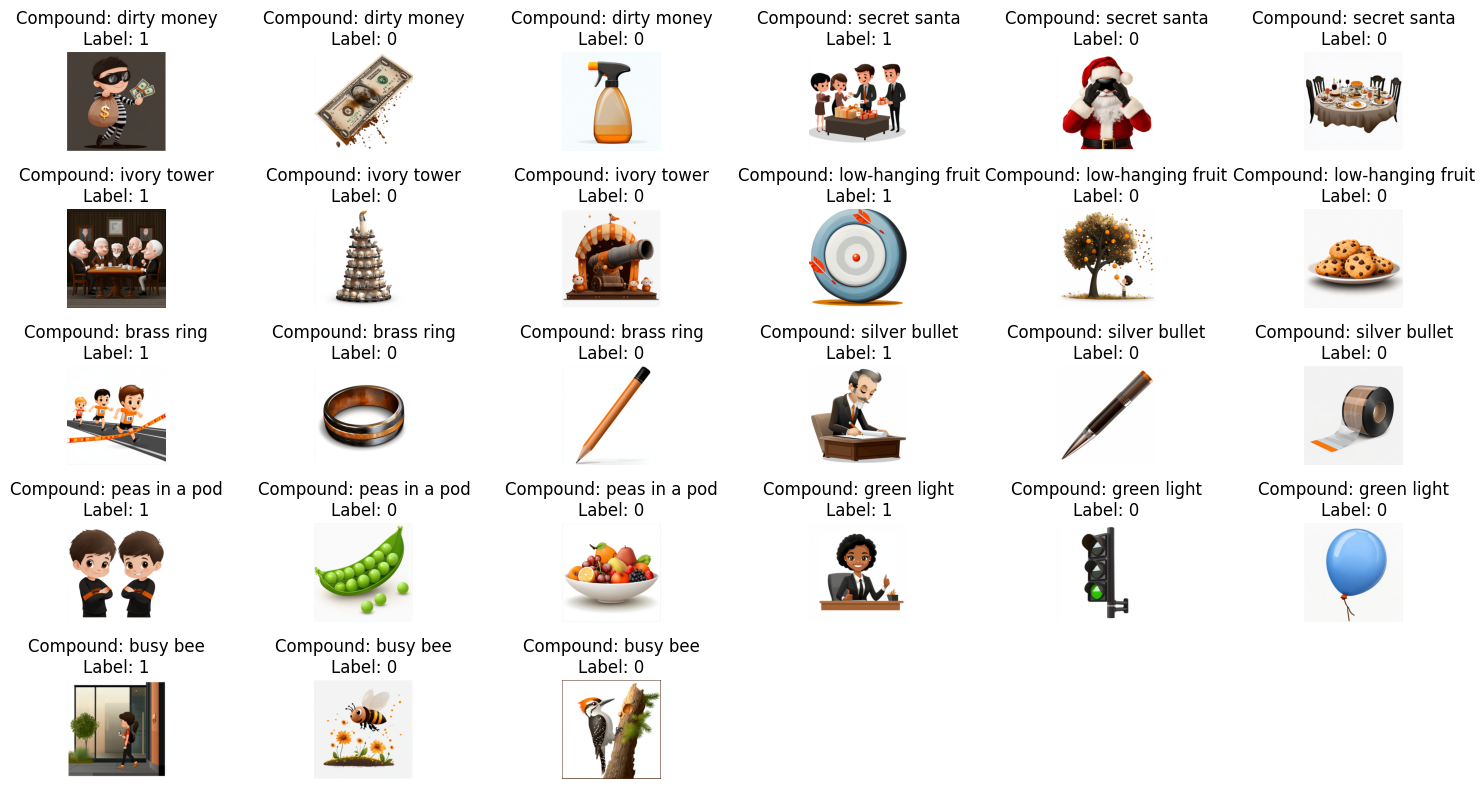

In [ ]:
# Visualise dataset. Note please don't try to visualize the whole training set, as there are many images.
image_folder = fpath+"test/images"

def visualise_data(df, image_folder):
    fig, axes = plt.subplots(len(df)//6+1, 6, figsize=(15, 8))
    axes = axes.flatten()

    for idx, row in df.iterrows():
        image_path = os.path.join(image_folder, row['image_name'])
        try:
            img = Image.open(image_path)
            ax = axes[idx]
            ax.imshow(img)
            ax.set_title(f"Compound: {row['compound']}\nLabel: {row['label']}")
            ax.axis('off')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")

    # Hide any empty subplots (those beyond the dataset size)
    for idx in range(len(df), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

visualise_data(test_df, fpath+"test/images")

In [ ]:
from torchvision import transforms

# Define the augmentation pipeline for training images
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Standard size for CLIP ViT models
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    # Note: Normalization is typically handled by CLIP's own preprocess,
    # but we define these standard augmentations as requested.
])

print("Augmentation pipeline 'train_transform' defined successfully.")

Augmentation pipeline 'train_transform' defined successfully.


In [ ]:
from torch.utils.data import Dataset

class IdiomaticDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): Dataframe containing image names and labels.
            image_dir (str): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # a. Retrieve the image file name and the label
        img_name = self.df.iloc[idx]['image_name']
        label = self.df.iloc[idx]['label']

        # b. Construct the full path
        img_path = os.path.join(self.image_dir, img_name)

        # c. Load the image and ensure RGB
        image = Image.open(img_path).convert('RGB')

        # d. Apply transform
        if self.transform:
            image = self.transform(image)

        # e. Return image and label
        return image, label

# 5. Instantiate the dataset
train_image_dir = os.path.join(fpath, "train/images")
train_dataset = IdiomaticDataset(
    dataframe=train_df,
    image_dir=train_image_dir,
    transform=train_transform
)

print(f"IdiomaticDataset class defined. Training dataset instantiated with {len(train_dataset)} samples.")

IdiomaticDataset class defined. Training dataset instantiated with 231 samples.


# Initialise model


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

print(f"Model loaded and running on: {device}")

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 118MiB/s]


Model loaded and running on: cuda


# Extract and preprocess features


In [ ]:
image_embeddings = []
text_embeddings = []

with torch.no_grad():
    for idx, row in test_df.iterrows():
        # Process Image
        image_path = os.path.join(image_folder, row['image_name'])
        image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        image_embeddings.append(image_features)

        # Process Text (using image_caption for zero-shot retrieval)
        # Added truncate=True to handle captions longer than 77 tokens
        text_tokens = clip.tokenize([row['image_caption']], truncate=True).to(device)
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        text_embeddings.append(text_features)

# Concatenate all features into tensors
image_embeddings = torch.cat(image_embeddings)
text_embeddings = torch.cat(text_embeddings)

print(f"Extracted {image_embeddings.shape[0]} image embeddings and {text_embeddings.shape[0]} text embeddings.")

Extracted 27 image embeddings and 27 text embeddings.


# Compute Cosine Similarity


In [ ]:
# Calculate cosine similarity using the normalized embeddings
# Dot product on normalized vectors is equivalent to cosine similarity
similarities = torch.sum(image_embeddings * text_embeddings, dim=-1).cpu().numpy()

# Add to dataframe
test_df['similarity_score'] = similarities.astype(float)

# Based on the observed similarity distribution (mostly 0.25-0.40),
# we use the median similarity as a heuristic threshold for binary classification
# to evaluate the model's ability to distinguish between pairs.
threshold = test_df['similarity_score'].median()
test_df['predicted_label'] = (test_df['similarity_score'] >= threshold).astype(int)

# Calculate basic metrics to evaluate the retrieval
accuracy = accuracy_score(test_df['label'], test_df['predicted_label'])
f1 = f1_score(test_df['label'], test_df['predicted_label'])

print(f"Similarity calculation complete. Heuristic Threshold: {threshold:.4f}")
print(f"Zero-shot Accuracy: {accuracy:.4f}")
print(f"Zero-shot F1-score: {f1:.4f}")
display(test_df[['image_name', 'label', 'similarity_score', 'predicted_label']].head())

Similarity calculation complete. Heuristic Threshold: 0.3401
Zero-shot Accuracy: 0.5185
Zero-shot F1-score: 0.4348


,image_name,label,similarity_score,predicted_label
0,08230960409.png,1,0.320312,0
1,46913780614.png,0,0.276123,0
2,58491774071.png,0,0.333740,0
3,12319434549.png,1,0.313965,0
4,05850548023.png,0,0.333496,0


# Evaluate Zero-Shot CLIP


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate comprehensive metrics
metrics = {
    'Accuracy': accuracy_score(test_df['label'], test_df['predicted_label']),
    'Precision': precision_score(test_df['label'], test_df['predicted_label']),
    'Recall': recall_score(test_df['label'], test_df['predicted_label']),
    'F1-Score': f1_score(test_df['label'], test_df['predicted_label'])
}

# Print a formatted summary
print("--- Zero-Shot Retrieval Performance Metrics ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

--- Zero-Shot Retrieval Performance Metrics ---
Accuracy: 0.5185
Precision: 0.3571
Recall: 0.5556
F1-Score: 0.4348


# Load augmented data

In [ ]:
from torch.utils.data import DataLoader

# 1. Instantiate the DataLoader
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# 2. Verify the DataLoader
print(f"DataLoader created with batch size: {batch_size}")
print(f"Total number of batches: {len(train_loader)}")

# 3. Quick check of one batch
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

DataLoader created with batch size: 32
Total number of batches: 8
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


# Train model

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Set the model to training mode
model.train()

# 2. Identify parameters to be optimized
# Since we are fine-tuning the entire CLIP model, we pass all parameters
optimizer = optim.Adam(
    model.parameters(),
    lr=5e-6,
    betas=(0.9, 0.98),
    eps=1e-6,
    weight_decay=0.2  # Optional but often used in CLIP fine-tuning
)

# 3. Define the loss function
# CrossEntropyLoss is used for the contrastive task
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

print(f"Optimizer: Adam (lr=5e-6)")
print(f"Loss Function: CrossEntropyLoss initialized for symmetric contrastive learning.")

Optimizer: Adam (lr=5e-6)
Loss Function: CrossEntropyLoss initialized for symmetric contrastive learning.


# Fine Tune model

In [ ]:
import torch
import numpy as np

# 1. Initialize loss history
epoch_losses = []
num_epochs = 5

# Note: To ensure we have captions, we'll re-run a small modification to the dataset
# or simply retrieve captions from the dataframe within the loop if indices are available.
# However, the standard CLIP contrastive loss expects (image, text) pairs in the batch.

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()

        # 3 & 4. Retrieve captions for the current batch from train_df and tokenize
        # Assuming the DataLoader preserves order or we map indices
        start_idx = i * batch_size
        end_idx = start_idx + images.size(0)
        batch_captions = train_df.iloc[start_idx:end_idx]['image_caption'].tolist()

        images = images.to(device)
        texts = clip.tokenize(batch_captions, truncate=True).to(device)

        # 5. Forward pass
        logits_per_image, logits_per_text = model(images, texts)

        # 6. Create ground truth labels (diagonal matrix index)
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)

        # 7. Calculate symmetric loss
        loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2

        # 8. Backward pass and update
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

print("Fine-tuning complete.")

Epoch [1/5], Average Loss: 4.5400
Epoch [2/5], Average Loss: 3.3142
Epoch [3/5], Average Loss: 3.2965
Epoch [4/5], Average Loss: 3.3076
Epoch [5/5], Average Loss: 3.2913
Fine-tuning complete.


In [ ]:
# Define the save path
model_save_path = "fine_tuned_clip_idioms.pt"

# Save the model state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model successfully saved to {model_save_path}")

Model successfully saved to fine_tuned_clip_idioms.pt


# Visualise Fine Tuning

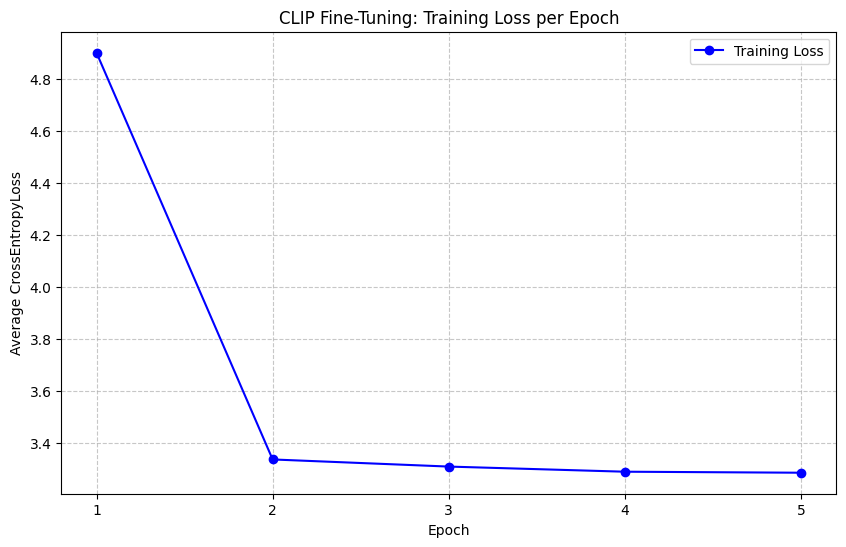

In [ ]:
import matplotlib.pyplot as plt

# Visualize the training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title('CLIP Fine-Tuning: Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average CrossEntropyLoss')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Evaluate Final Model

In [ ]:
# 1. Set the model to evaluation mode
model.eval()

# 2. Initialize empty lists
val_image_embeddings = []
val_text_embeddings = []
val_image_folder = os.path.join(fpath, 'val/images')

# 5. Ensure operations are in no_grad context
with torch.no_grad():
    for idx, row in val_df.iterrows():
        # 3a. Load and preprocess image
        img_path = os.path.join(val_image_folder, row['image_name'])
        image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

        # 3b. Encode and normalize image features
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        val_image_embeddings.append(image_features)

        # 3c. Tokenize caption
        text_tokens = clip.tokenize([row['image_caption']], truncate=True).to(device)

        # 3d. Encode and normalize text features
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        val_text_embeddings.append(text_features)

# 4. Concatenate features into single tensors
val_image_embeddings = torch.cat(val_image_embeddings)
val_text_embeddings = torch.cat(val_text_embeddings)

print(f'Successfully extracted validation features.')
print(f'Val Image Embeddings Shape: {val_image_embeddings.shape}')
print(f'Val Text Embeddings Shape: {val_text_embeddings.shape}')

Successfully extracted validation features.
Val Image Embeddings Shape: torch.Size([27, 512])
Val Text Embeddings Shape: torch.Size([27, 512])


In [ ]:
import torch
import numpy as np

# 1. Calculate cosine similarity using row-wise dot product of normalized embeddings
# Since embeddings were already normalized in the extraction step, dot product = cosine similarity
val_similarities = torch.sum(val_image_embeddings * val_text_embeddings, dim=-1).cpu().numpy()

# 2. Add similarity scores to val_df
val_df['similarity_score'] = val_similarities.astype(float)

# 3. Print the first few rows to verify
print('Similarity scores calculated and added to val_df.')
display(val_df[['compound', 'image_name', 'label', 'similarity_score']].head())

Similarity scores calculated and added to val_df.


,compound,image_name,label,similarity_score
0,high life,40542311053.png,1,0.233887
1,high life,49177713448.png,0,0.229492
2,high life,39122642061.png,0,0.233032
3,loan shark,92619052441.png,1,0.231323
4,loan shark,75567985354.png,0,0.234497


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Determine classification threshold using median similarity
val_threshold = val_df['similarity_score'].median()
val_df['predicted_label'] = (val_df['similarity_score'] >= val_threshold).astype(int)

# 2. Calculate metrics
val_accuracy = accuracy_score(val_df['label'], val_df['predicted_label'])
val_precision = precision_score(val_df['label'], val_df['predicted_label'])
val_recall = recall_score(val_df['label'], val_df['predicted_label'])
val_f1 = f1_score(val_df['label'], val_df['predicted_label'])

# 3. Print performance summary
print(f'--- Validation Performance Metrics ---')
print(f'Heuristic Threshold: {val_threshold:.4f}')
print(f'Accuracy:  {val_accuracy:.4f}')
print(f'Precision: {val_precision:.4f}')
print(f'Recall:    {val_recall:.4f}')
print(f'F1-Score:  {val_f1:.4f}')

--- Validation Performance Metrics ---
Heuristic Threshold: 0.2352
Accuracy:  0.5185
Precision: 0.3571
Recall:    0.5556
F1-Score:  0.4348


# Test for Demo


In [ ]:
import os

file_name = "TestImages.zip"

if os.path.exists(file_name):
  print("File Exists, beginnning unzip")
  !unzip "TestImages"
  print("File unzipped")
else:
  print("File not found, please upload into session")

File Exists, beginnning unzip
Archive:  TestImages.zip
replace TestImages/39122642061.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: File unzipped


In [ ]:
ground_truth_file = "/content/ground_truth_labels.xlsx"

input_test_image_1 = "/content/TestImages/39122642061.png"
input_test_image_2 = "/content/TestImages/40542311053.png"
input_test_image_3 = "/content/TestImages/49177713448.png"
input_compound = "high life"
input_sentence = "It just showed how she still lived the high life while everyone else endured rationing."

vision_transformer_model = "/content/fine_tuned_clip_idioms.pt"

In [ ]:
import torch
import clip

# 1. Determine the available device
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load the CLIP model and preprocessor
model, preprocess = clip.load("ViT-B/32", device=device)

# 3. Load the fine-tuned state dictionary
# Using the variable vision_transformer_model defined in a previous cell
state_dict = torch.load(vision_transformer_model, map_location=device)

# 4. Map the state dictionary to the model
model.load_state_dict(state_dict)

# 5. Set model to evaluation mode
model.eval()

print(f"Fine-tuned CLIP model loaded successfully from {vision_transformer_model} on {device}.")

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 70.9MiB/s]


Fine-tuned CLIP model loaded successfully from /content/fine_tuned_clip_idioms.pt on cuda.


In [ ]:
from PIL import Image

# 1. Create a list of image paths
demo_image_paths = [input_test_image_1, input_test_image_2, input_test_image_3]

# 2 & 3. Preprocess and stack images
preprocessed_images = []
for path in demo_image_paths:
    img = Image.open(path).convert("RGB")
    preprocessed_images.append(preprocess(img))

# Stack images into a single tensor [3, 3, 224, 224] and move to device
demo_images_tensor = torch.stack(preprocessed_images).to(device)

# 4. Tokenize the input sentence and move to device
demo_text_tensor = clip.tokenize([input_sentence], truncate=True).to(device)

print(f"Preprocessed {len(demo_image_paths)} images. Shape: {demo_images_tensor.shape}")
print(f"Tokenized sentence. Shape: {demo_text_tensor.shape}")

Preprocessed 3 images. Shape: torch.Size([3, 3, 224, 224])
Tokenized sentence. Shape: torch.Size([1, 77])


In [ ]:
with torch.no_grad():
    # 1. Extract image and text features
    image_features = model.encode_image(demo_images_tensor)
    text_features = model.encode_text(demo_text_tensor)

    # 2. Normalize the features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # 3. Calculate cosine similarity
    # Matrix multiplication: [3, 512] @ [1, 512].T -> [3, 1]
    demo_similarities = (image_features @ text_features.T).cpu().numpy()

print(f"Calculated similarity scores for {demo_similarities.shape[0]} images.")
print(f"Scores: {demo_similarities.flatten()}")

Calculated similarity scores for 3 images.
Scores: [0.2108 0.2299 0.2125]


In [ ]:
import pandas as pd

# 1. Load ground truth labels
ground_truth_df = pd.read_excel(ground_truth_file)

# 2. Identify the image with the highest similarity score
# demo_similarities is [3, 1], so we flatten it to get indices
max_sim_idx = demo_similarities.flatten().argmax()
predicted_image_path = demo_image_paths[max_sim_idx]
predicted_filename = os.path.basename(predicted_image_path)

# 3. Search for the ground truth of the predicted image
# We assume the 'image_name' column in the Excel matches the filename
prediction_entry = ground_truth_df[ground_truth_df['image_name'] == predicted_filename]

if not prediction_entry.empty:
    actual_label = prediction_entry['label'].values[0]
    is_correct = (actual_label == 1)
    print(f"Predicted Image: {predicted_filename}")
    print(f"Similarity Score: {demo_similarities.flatten()[max_sim_idx]:.4f}")
    print(f"Ground Truth Label: {actual_label}")
    print(f"Correctly identified idiomatic representation: {is_correct}")
else:
    print(f"Filename {predicted_filename} not found in ground truth file.")

display(ground_truth_df)

Predicted Image: 40542311053.png
Similarity Score: 0.2299
Ground Truth Label: 1
Correctly identified idiomatic representation: True


,image_name,label
0,40542311053.png,1
1,49177713448.png,0
2,39122642061.png,0


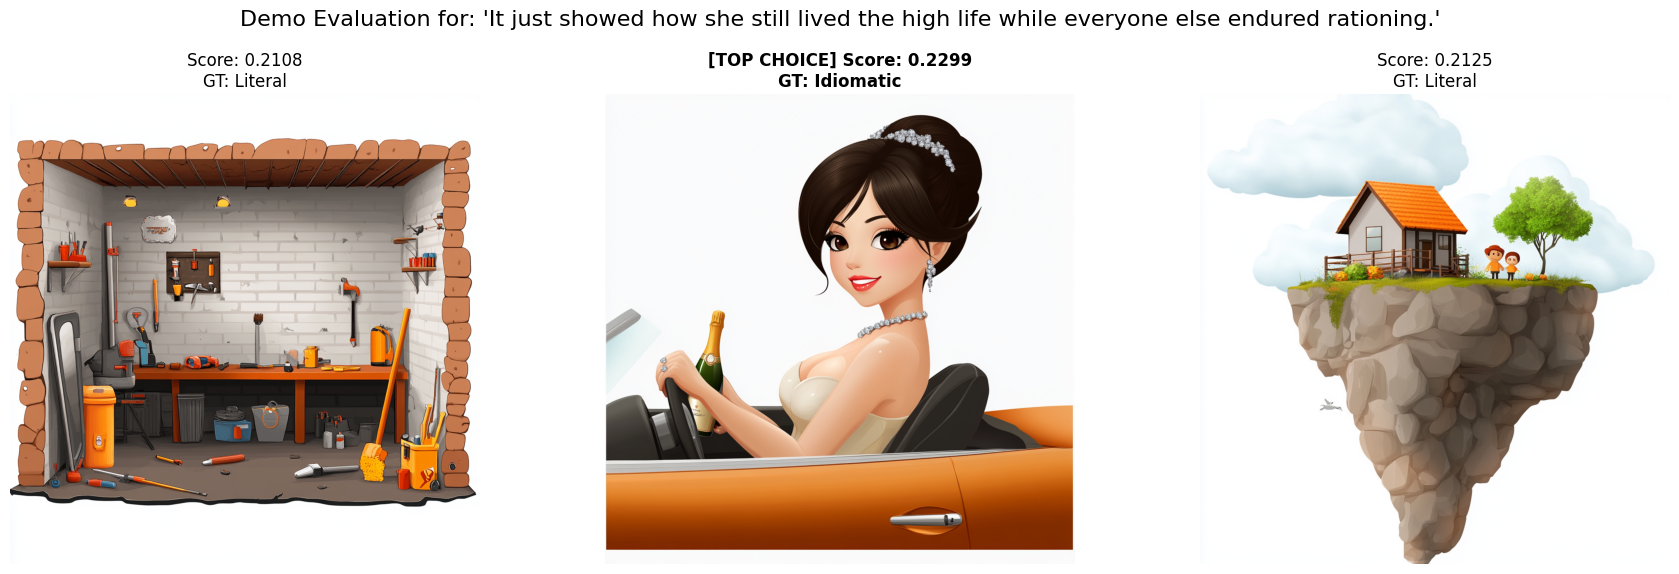

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. Setup the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sim_scores = demo_similarities.flatten()
max_idx = sim_scores.argmax()

# 2. Iterate through demo images to plot
for i, (img_path, score) in enumerate(zip(demo_image_paths, sim_scores)):
    # Load image
    img = Image.open(img_path)
    filename = os.path.basename(img_path)

    # Get ground truth label
    gt_label = ground_truth_df[ground_truth_df['image_name'] == filename]['label'].values[0]
    label_text = "Idiomatic" if gt_label == 1 else "Literal"

    # Highlight top choice
    title_prefix = "[TOP CHOICE] " if i == max_idx else ""

    # Plotting
    axes[i].imshow(img)
    axes[i].set_title(f"{title_prefix}Score: {score:.4f}\nGT: {label_text}",
                      fontsize=12, fontweight='bold' if i == max_idx else 'normal')
    axes[i].axis('off')

plt.suptitle(f"Demo Evaluation for: '{input_sentence}'", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()